#  Sequence Pattern Analysis : 
In Notebook 02, we counted events. But counting is like reading a book by counting how many times each word appears
Consider two traces:
- `[E5, E22, E5, E9, E11, E26, E2, E21]` → Block allocated, received, stored, verified, deleted. **Normal lifecycle.**
- `[E5, E22, E5, E7, E12, E14, E20]` → Block allocated, received... then write error, mirror error, receive error, delete error. **Cascading failure.**

Both have similar event COUNTS, but the SEQUENCE tells a completely different story. This is exactly what our CoT agent needs to understand.




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import ast
import os
from itertools import islice
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
# Load event traces
DATA_DIR = "../../preprocessed"
traces_df = pd.read_csv(os.path.join(DATA_DIR, "Event_traces.csv"))
templates_df = pd.read_csv(os.path.join(DATA_DIR, "HDFS.log_templates.csv"))

##  Step 1: Parse Event Sequences

The `Features` column in our traces CSV stores event sequences as strings that look like lists: `"[E5, E22, E5, E11, ...]"`. We need to convert these strings into actual Python lists so we can analyze the order.

**Concept — Why strings aren't lists**: When pandas reads a CSV, everything is text. The string `"[E5, E22]"` looks like a list but it's actually 10 characters of text. We use `ast.literal_eval()` to safely convert it to a real Python list `['E5', 'E22']`.


In [3]:
traces_df.head(10)
traces_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 575061 entries, 0 to 575060
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   BlockId       575061 non-null  str    
 1   Label         575061 non-null  str    
 2   Type          16838 non-null   float64
 3   Features      575061 non-null  str    
 4   TimeInterval  575061 non-null  str    
 5   Latency       575061 non-null  int64  
dtypes: float64(1), int64(1), str(4)
memory usage: 26.3 MB


In [ ]:


def parse_sequence(feat_str):
    if not isinstance(feat_str, str):
        return []

    feat_str = feat_str.strip()

    if feat_str.startswith("[") and feat_str.endswith("]"):
        feat_str = feat_str[1:-1]

    if not feat_str:
        return []

    return [x.strip() for x in feat_str.split(",")]


traces_df["sequence"] = traces_df["Features"].apply(parse_sequence)
traces_df["seq_length"] = traces_df["sequence"].str.len()

# Split into normal and anomaly
normal_traces = traces_df[traces_df['Label'] == 'Success']
anomaly_traces = traces_df[traces_df['Label'] == 'Fail']

print(f" Parsed!")
print(f"   Normal traces:  {len(normal_traces):,}")
print(f"   Anomaly traces: {len(anomaly_traces):,}")
print(f"\n   Sequence length stats:")
print(f"   {'':>15} {'Normal':>10} {'Anomaly':>10}")
print(f"   {'Mean':<15} {normal_traces['seq_length'].mean():>10.1f} {anomaly_traces['seq_length'].mean():>10.1f}")
print(f"   {'Median':<15} {normal_traces['seq_length'].median():>10.1f} {anomaly_traces['seq_length'].median():>10.1f}")
print(f"   {'Min':<15} {normal_traces['seq_length'].min():>10} {anomaly_traces['seq_length'].min():>10}")
print(f"   {'Max':<15} {normal_traces['seq_length'].max():>10} {anomaly_traces['seq_length'].max():>10}")


✅ Parsed!
   Normal traces:  558,223
   Anomaly traces: 16,838

   Sequence length stats:
                       Normal    Anomaly
   Mean                  19.5       17.1
   Median                19.0       20.0
   Min                     13          2
   Max                    298        284


In [9]:
traces_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 575061 entries, 0 to 575060
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   BlockId       575061 non-null  str    
 1   Label         575061 non-null  str    
 2   Type          16838 non-null   float64
 3   Features      575061 non-null  str    
 4   TimeInterval  575061 non-null  str    
 5   Latency       575061 non-null  int64  
 6   sequence      575061 non-null  object 
 7   seq_length    575061 non-null  int64  
dtypes: float64(1), int64(2), object(1), str(4)
memory usage: 35.1+ MB


In [ ]:
traces_df.head(10)  

,BlockId,Label,Type,Features,TimeInterval,Latency,sequence,seq_length
0,blk_-1608999687919862906,Success,NaN,"[E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3802,"[E5, E22, E5, E5, E11, E11, E9, E9, E11, E9, E...",269
1,blk_7503483334202473044,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3802,"[E5, E5, E22, E5, E11, E9, E11, E9, E11, E9, E...",22
2,blk_-3544583377289625738,Fail,21.0,"[E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E3,E26,E26,...","[0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...",3797,"[E5, E22, E5, E5, E11, E9, E11, E9, E11, E9, E...",223
3,blk_-9073992586687739851,Success,NaN,"[E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",50448,"[E5, E22, E5, E5, E11, E9, E11, E9, E11, E9, E...",22
4,blk_7854771516489510256,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 1.0, 48.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",50583,"[E5, E5, E22, E5, E11, E9, E11, E9, E11, E9, E...",38
5,blk_1717858812220360316,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...","[0.0, 0.0, 11.0, 43.0, 0.0, 0.0, 0.0, 0.0, 0.0...",50458,"[E5, E5, E22, E5, E11, E9, E11, E9, E11, E9, E...",38
6,blk_-2519617320378473615,Success,NaN,"[E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...","[0.0, 1.0, 9.0, 43.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",50523,"[E5, E22, E5, E5, E11, E11, E9, E9, E11, E9, E...",38
7,blk_7063315473424667801,Success,NaN,"[E5,E5,E5,E22,E11,E9,E11,E9,E26,E26,E11,E9,E26...","[1.0, 0.0, 0.0, 58.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",50818,"[E5, E5, E5, E22, E11, E9, E11, E9, E26, E26, ...",38
8,blk_8586544123689943463,Success,NaN,"[E5,E5,E5,E22,E11,E9,E11,E11,E9,E9,E26,E26,E26...","[1.0, 0.0, 0.0, 36.0, 0.0, 1.0, 0.0, 0.0, 0.0,...",50795,"[E5, E5, E5, E22, E11, E9, E11, E11, E9, E9, E...",38
9,blk_2765344736980045501,Success,NaN,"[E5,E5,E22,E5,E11,E9,E11,E9,E26,E11,E9,E26,E26...","[0.0, 0.0, 1.0, 28.0, 0.0, 0.0, 0.0, 0.0, 1.0,...",50528,"[E5, E5, E22, E5, E11, E9, E11, E9, E26, E11, ...",38


##  Sequence Length:
**Intuition**: If a block operation fails, does it:
- **Die quickly** (short sequence — crashed early)?
- **Thrash around** (long sequence — retries, cascading errors)?

The length distribution tells us which pattern dominates.


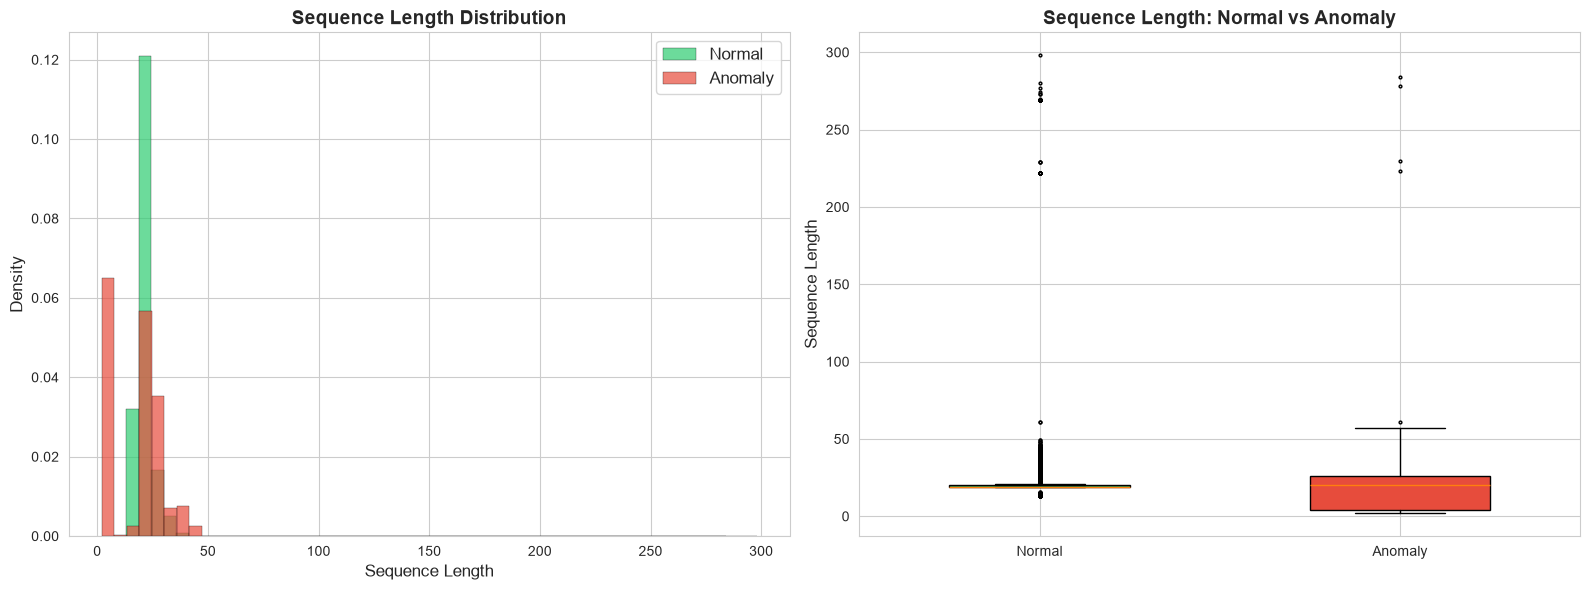

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


axes[0].hist(normal_traces['seq_length'], bins=50, alpha=0.7, color='#2ecc71', 
             label='Normal', density=True, edgecolor='black', linewidth=0.3)
axes[0].hist(anomaly_traces['seq_length'], bins=50, alpha=0.7, color='#e74c3c', 
             label='Anomaly', density=True, edgecolor='black', linewidth=0.3)
axes[0].set_xlabel('Sequence Length', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Sequence Length Distribution', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=12)


box_data = [normal_traces['seq_length'].values, anomaly_traces['seq_length'].values]
bp = axes[1].boxplot(
    box_data,
    tick_labels=['Normal', 'Anomaly'],
    patch_artist=True,
    widths=0.5,
    showfliers=True,
    flierprops={'markersize': 2}
)

bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[1].set_ylabel('Sequence Length', fontsize=12)
axes[1].set_title('Sequence Length: Normal vs Anomaly', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/sequence_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()


A concise interpretation suitable for a report

Figure 1 compares the distribution of sequence lengths for normal and anomalous HDFS traces. Normal traces exhibit a narrow distribution centered around approximately 18–20 log events, indicating highly consistent execution behavior. In contrast, anomalous traces display a much broader distribution, reflecting greater variability in execution paths and failure points. The box plot further confirms this observation by showing a substantially larger interquartile range for anomalous traces while both classes have similar median sequence lengths. Although sequence length provides useful information about execution behavior, the considerable overlap between the two distributions indicates that it is insufficient as a standalone feature for anomaly detection. Consequently, richer sequential information, such as event ordering and temporal dependencies, is required to accurately distinguish normal from anomalous executions.

In [11]:
import matplotlib
print(matplotlib.__version__)

3.11.0


## Step 3: How Do Traces Start and End?

**Concept**: In a healthy system, block operations follow a predictable lifecycle:
- **Start**: Allocate block (E22), receive data (E5)
- **End**: Delete block (E21), verify (E2), serve (E3)

If anomalies start or end with DIFFERENT events, that tells us exactly WHERE in the lifecycle things break.


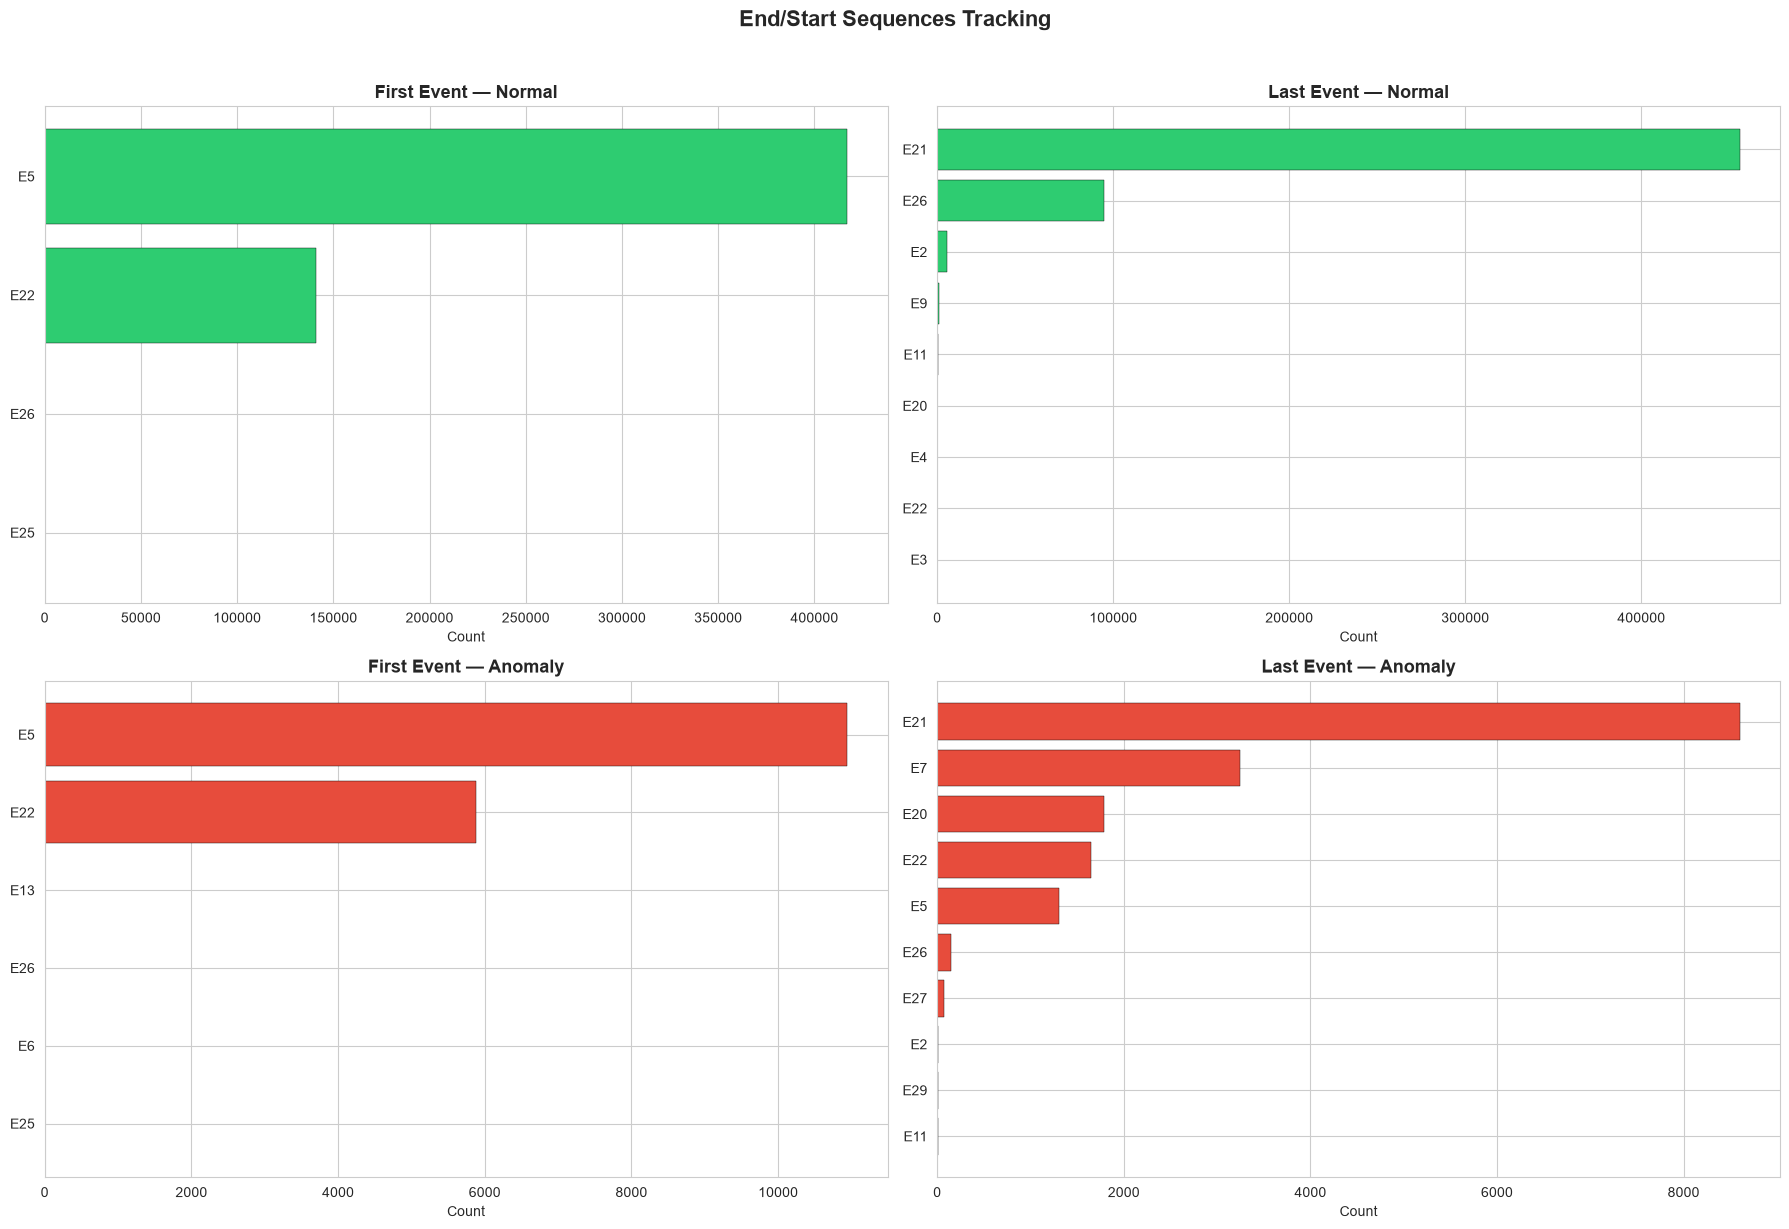

In [14]:
# Extract first and last event from each sequence
def get_first_last(seq):
    if len(seq) == 0:
        return None, None
    return seq[0], seq[-1]

traces_df['first_event'] = traces_df['sequence'].apply(lambda s: s[0] if len(s) > 0 else None)
traces_df['last_event'] = traces_df['sequence'].apply(lambda s: s[-1] if len(s) > 0 else None)

# Compare first events
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for idx, (col, title) in enumerate([('first_event', 'First Event'), ('last_event', 'Last Event')]):
    # Normal
    normal_counts = traces_df[traces_df['Label']=='Success'][col].value_counts().head(10)
    axes[0][idx].barh(normal_counts.index, normal_counts.values, color='#2ecc71', edgecolor='black', linewidth=0.3)
    axes[0][idx].set_title(f'{title} — Normal', fontsize=13, fontweight='bold')
    axes[0][idx].set_xlabel('Count')
    axes[0][idx].invert_yaxis()
    
    # Anomaly
    anomaly_counts = traces_df[traces_df['Label']=='Fail'][col].value_counts().head(10)
    axes[1][idx].barh(anomaly_counts.index, anomaly_counts.values, color='#e74c3c', edgecolor='black', linewidth=0.3)
    axes[1][idx].set_title(f'{title} — Anomaly', fontsize=13, fontweight='bold')
    axes[1][idx].set_xlabel('Count')
    axes[1][idx].invert_yaxis()

plt.suptitle('End/Start Sequences Tracking', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/first_last_events.png', dpi=150, bbox_inches='tight')
plt.show()


##  Step 4: N-gram Analysis 

**Concept — N-grams**: An n-gram is a contiguous subsequence of length n. For the sequence `[E5, E22, E5, E7]`:
- **Bigrams** (n=2): `(E5,E22)`, `(E22,E5)`, `(E5,E7)`
- **Trigrams** (n=3): `(E5,E22,E5)`, `(E22,E5,E7)`

By comparing n-gram frequencies between Normal and Anomaly, we find **event chains unique to failures**. For example, the bigram `(E7, E12)` — write error followed by mirror error — might only appear in anomalies.




In [ ]:


def extract_ngrams(sequence, n):
    
    return list(zip(*[sequence[i:] for i in range(n)]))



normal_bigrams = Counter()
anomaly_bigrams = Counter()

for _, row in normal_traces.iterrows():
    normal_bigrams.update(extract_ngrams(row['sequence'], 2))

for _, row in anomaly_traces.iterrows():
    anomaly_bigrams.update(extract_ngrams(row['sequence'], 2))

print(f"Unique bigrams in Normal:  {len(normal_bigrams):,}")
print(f"Unique bigrams in Anomaly: {len(anomaly_bigrams):,}")

# Top 15 bigrams for each
print("\n Top 15 Normal bigrams:")
for bigram, count in normal_bigrams.most_common(15):
    print(f"   {str(bigram):<20} {count:>10,}")

print("\n Top 15 Anomaly bigrams:")
for bigram, count in anomaly_bigrams.most_common(15):
    print(f"   {str(bigram):<20} {count:>10,}")


Unique bigrams in Normal:  137
Unique bigrams in Anomaly: 274

🟢 Top 15 Normal bigrams:
   ('E11', 'E9')         1,652,264
   ('E26', 'E26')        1,000,199
   ('E9', 'E11')           991,344
   ('E23', 'E23')          909,573
   ('E21', 'E21')          909,022
   ('E5', 'E5')            888,131
   ('E9', 'E26')           565,862
   ('E23', 'E21')          453,896
   ('E5', 'E22')           416,514
   ('E22', 'E5')           367,461
   ('E26', 'E23')          267,133
   ('E5', 'E11')           262,660
   ('E26', 'E11')          225,157
   ('E4', 'E3')            194,383
   ('E3', 'E4')            189,930

🔴 Top 15 Anomaly bigrams:
   ('E11', 'E9')            31,381
   ('E23', 'E23')           21,586
   ('E26', 'E26')           20,612
   ('E5', 'E5')             19,608
   ('E9', 'E11')            17,629
   ('E21', 'E21')           16,613
   ('E5', 'E22')            10,929
   ('E22', 'E5')            10,764
   ('E23', 'E21')           10,179
   ('E9', 'E26')            10,012
   ('E26',

In [ ]:

normal_trigrams = Counter()
anomaly_trigrams = Counter()

for _, row in normal_traces.iterrows():
    normal_trigrams.update(extract_ngrams(row['sequence'], 3))

for _, row in anomaly_traces.iterrows():
    anomaly_trigrams.update(extract_ngrams(row['sequence'], 3))

print(f"Unique trigrams in Normal:  {len(normal_trigrams):,}")
print(f"Unique trigrams in Anomaly: {len(anomaly_trigrams):,}")


print("\n Top 15 Normal trigrams:")
for trigram, count in normal_trigrams.most_common(15):
    print(f"   {str(trigram):<20} {count:>10,}")

print("\n Top 15 Anomaly trigrams:")
for trigram, count in anomaly_trigrams.most_common(15):
    print(f"   {str(trigram):<20} {count:>10,}")

Unique trigrams in Normal:  545
Unique trigrams in Anomaly: 939

🟢 Top 15 Normal trigrams:
   ('E9', 'E11', 'E9')     981,247
   ('E11', 'E9', 'E11')    979,851
   ('E11', 'E9', 'E26')    555,886
   ('E9', 'E26', 'E26')    462,996
   ('E23', 'E23', 'E23')    454,895
   ('E21', 'E21', 'E21')    454,348
   ('E23', 'E23', 'E21')    453,896
   ('E23', 'E21', 'E21')    453,769
   ('E26', 'E26', 'E26')    441,558
   ('E5', 'E5', 'E5')      330,726
   ('E5', 'E5', 'E22')     297,900
   ('E26', 'E23', 'E23')    267,133
   ('E5', 'E11', 'E9')     261,871
   ('E22', 'E5', 'E5')     259,312
   ('E26', 'E26', 'E23')    238,917

🔴 Top 15 Anomaly trigrams:
   ('E9', 'E11', 'E9')      17,411
   ('E11', 'E9', 'E11')     17,372
   ('E23', 'E23', 'E23')     11,250
   ('E23', 'E23', 'E21')     10,179
   ('E11', 'E9', 'E26')      9,829
   ('E23', 'E21', 'E21')      8,670
   ('E9', 'E26', 'E26')      7,937
   ('E26', 'E26', 'E26')      6,940
   ('E22', 'E5', 'E5')       6,705
   ('E5', 'E5', 'E22')       6

In [ ]:

normal_4grams = Counter()
anomaly_4grams = Counter()

for _, row in normal_traces.iterrows():
    normal_4grams.update(extract_ngrams(row['sequence'], 4))

for _, row in anomaly_traces.iterrows():
    anomaly_4grams.update(extract_ngrams(row['sequence'], 4))

print(f"Unique 4-grams in Normal:  {len(normal_4grams):,}")
print(f"Unique 4-grams in Anomaly: {len(anomaly_4grams):,}")


print("\nTop 15 Normal 4-grams:")
for fourgram, count in normal_4grams.most_common(15):
    print(f"   {str(fourgram):<20} {count:>10,}")

print("\n Top 15 Anomaly 4-grams:")
for fourgram, count in anomaly_4grams.most_common(15):
    print(f"   {str(fourgram):<20} {count:>10,}")

Unique 4-grams in Normal:  1,436
Unique 4-grams in Anomaly: 2,172

🟢 Top 15 Normal 4-grams:
   ('E11', 'E9', 'E11', 'E9')    971,028
   ('E9', 'E11', 'E9', 'E26')    461,183
   ('E11', 'E9', 'E26', 'E26')    457,197
   ('E23', 'E23', 'E23', 'E21')    453,896
   ('E23', 'E23', 'E21', 'E21')    453,769
   ('E23', 'E21', 'E21', 'E21')    453,383
   ('E9', 'E11', 'E9', 'E11')    434,976
   ('E9', 'E26', 'E26', 'E26')    367,041
   ('E26', 'E23', 'E23', 'E23')    267,133
   ('E26', 'E26', 'E23', 'E23')    238,917
   ('E5', 'E11', 'E9', 'E11')    233,844
   ('E26', 'E26', 'E26', 'E23')    212,728
   ('E5', 'E5', 'E5', 'E22')    189,810
   ('E5', 'E5', 'E22', 'E11')    184,568
   ('E5', 'E22', 'E11', 'E9')    184,189

🔴 Top 15 Anomaly 4-grams:
   ('E11', 'E9', 'E11', 'E9')     17,201
   ('E23', 'E23', 'E23', 'E21')     10,178
   ('E23', 'E23', 'E21', 'E21')      8,670
   ('E9', 'E11', 'E9', 'E26')      7,859
   ('E11', 'E9', 'E26', 'E26')      7,844
   ('E9', 'E11', 'E9', 'E11')      7,441
  

##  Step 5: Anomaly-Exclusive Patterns 

Now the most powerful analysis: which bigrams appear **ONLY** in anomaly traces and **NEVER** in normal ones? These are the event transitions that are 100% indicative of failure.




In [ ]:
# Find bigrams that appear in anomaly but NOT in normal
anomaly_only_bigrams = {bg: count for bg, count in anomaly_bigrams.items() 
                        if bg not in normal_bigrams}

# Find bigrams that appear in normal but NOT in anomaly  
normal_only_bigrams = {bg: count for bg, count in normal_bigrams.items() 
                       if bg not in anomaly_bigrams}

print(f" Bigrams EXCLUSIVE to anomalies: {len(anomaly_only_bigrams)}")
print(f" Bigrams EXCLUSIVE to normal:    {len(normal_only_bigrams)}")

# Show the anomaly-exclusive ones sorted by frequency
print(f"\n{'─'*55}")
print(f"  ANOMALY-EXCLUSIVE BIGRAMS (sorted by frequency)")
print(f"{'─'*55}")

sorted_exclusive = sorted(anomaly_only_bigrams.items(), key=lambda x: x[1], reverse=True)
for bigram, count in sorted_exclusive[:20]:
    e1, e2 = bigram
    # Look up what these events mean
    t1 = templates_df[templates_df['EventId']==e1]['EventTemplate'].values
    t2 = templates_df[templates_df['EventId']==e2]['EventTemplate'].values
    t1 = t1[0][:40] if len(t1) > 0 else "?"
    t2 = t2[0][:40] if len(t2) > 0 else "?"
    print(f"\n   {e1} → {e2}  (count: {count:,})")
    print(f"      {e1}: {t1}")
    print(f"      {e2}: {t2}")


🔴 Bigrams EXCLUSIVE to anomalies: 143
🟢 Bigrams EXCLUSIVE to normal:    6

───────────────────────────────────────────────────────
  ANOMALY-EXCLUSIVE BIGRAMS (sorted by frequency)
───────────────────────────────────────────────────────

   E5 → E7  (count: 1,993)
      E5: [*]Receiving block[*]src:[*]dest:[*]
      E7: [*]writeBlock[*]received exception[*]

   E22 → E7  (count: 1,264)
      E22: [*]BLOCK* NameSystem[*]allocateBlock:[*]
      E7: [*]writeBlock[*]received exception[*]

   E13 → E11  (count: 1,194)
      E13: [*]Receiving empty packet for block[*]
      E11: [*]PacketResponder[*]for block[*]termina

   E9 → E13  (count: 781)
      E9: [*]Received block[*]of size[*]from[*]
      E13: [*]Receiving empty packet for block[*]

   E4 → E25  (count: 345)
      E4: [*]Got exception while serving[*]to[*]
      E25: [*]BLOCK* ask[*]to replicate[*]to[*]

   E27 → E23  (count: 276)
      E27: [*]BLOCK* NameSystem[*]addStoredBlock: R
      E23: [*]BLOCK* NameSystem[*]delete:[*]is add

In [ ]:
# Find TRIgrams that appear in anomaly but NOT in normal
anomaly_only_trigrams = {tr: count for tr, count in anomaly_trigrams.items() 
                         if tr not in normal_trigrams}

# Find trigrams that appear in normal but NOT in anomaly  
normal_only_trigrams = {tr: count for tr, count in normal_trigrams.items() 
                       if tr not in anomaly_trigrams}

print(f" Trigrams EXCLUSIVE to anomalies: {len(anomaly_only_trigrams)}")
print(f" Trigrams EXCLUSIVE to normal:    {len(normal_only_trigrams)}")

# Show the anomaly-exclusive ones sorted by frequency
print(f"\n{'─'*55}")
print(f"  ANOMALY-EXCLUSIVE TRIGRAMS (sorted by frequency)")
print(f"{'─'*55}")

sorted_exclusive = sorted(anomaly_only_trigrams.items(), key=lambda x: x[1], reverse=True)
for trigram, count in sorted_exclusive[:20]:
    e1, e2, e3 = trigram
    # Look up what these events mean
    t1 = templates_df[templates_df['EventId']==e1]['EventTemplate'].values
    t2 = templates_df[templates_df['EventId']==e2]['EventTemplate'].values
    t3 = templates_df[templates_df['EventId']==e3]['EventTemplate'].values
    t1 = t1[0][:40] if len(t1) > 0 else "?"
    t2 = t2[0][:40] if len(t2) > 0 else "?"
    t3 = t3[0][:40] if len(t3) > 0 else "?"
    print(f"\n   {e1} → {e2} → {e3}  (count: {count:,})")
    print(f"      {e1}: {t1}")
    print(f"      {e2}: {t2}")
    print(f"      {e3}: {t3}")


🔴 Trigrams EXCLUSIVE to anomalies: 0
🟢 Trigrams EXCLUSIVE to normal:    0

───────────────────────────────────────────────────────
  ANOMALY-EXCLUSIVE TRIGRAMS (sorted by frequency)
───────────────────────────────────────────────────────


In [31]:
# Find 4-grams that appear in anomaly but NOT in normal
anomaly_only_fourgrams = {fg: count for fg, count in anomaly_4grams.items() 
                          if fg not in normal_4grams}

# Find 4-grams that appear in normal but NOT in anomaly  
normal_only_fourgrams = {fg: count for fg, count in normal_4grams.items() 
                       if fg not in anomaly_4grams}

print(f"🔴 4-grams EXCLUSIVE to anomalies: {len(anomaly_only_fourgrams)}")
print(f"🟢 4-grams EXCLUSIVE to normal:    {len(normal_only_fourgrams)}")

# Show the anomaly-exclusive ones sorted by frequency
print(f"\n{'─'*55}")
print(f"  ANOMALY-EXCLUSIVE 4-GRAMS (sorted by frequency)")
print(f"{'─'*55}")

sorted_exclusive = sorted(anomaly_only_fourgrams.items(), key=lambda x: x[1], reverse=True)
for fourgram, count in sorted_exclusive[:20]:
    e1, e2, e3, e4 = fourgram
    # Look up what these events mean
    t1 = templates_df[templates_df['EventId']==e1]['EventTemplate'].values
    t2 = templates_df[templates_df['EventId']==e2]['EventTemplate'].values
    t3 = templates_df[templates_df['EventId']==e3]['EventTemplate'].values
    t4 = templates_df[templates_df['EventId']==e4]['EventTemplate'].values
    t1 = t1[0][:40] if len(t1) > 0 else "?"
    t2 = t2[0][:40] if len(t2) > 0 else "?"
    t3 = t3[0][:40] if len(t3) > 0 else "?"
    t4 = t4[0][:40] if len(t4) > 0 else "?"
    print(f"\n   {e1} → {e2} → {e3} → {e4}  (count: {count:,})")
    print(f"      {e1}: {t1}")
    print(f"      {e2}: {t2}")
    print(f"      {e3}: {t3}")
    print(f"      {e4}: {t4}")


🔴 4-grams EXCLUSIVE to anomalies: 1233
🟢 4-grams EXCLUSIVE to normal:    497

───────────────────────────────────────────────────────
  ANOMALY-EXCLUSIVE 4-GRAMS (sorted by frequency)
───────────────────────────────────────────────────────

   E22 → E5 → E5 → E7  (count: 1,365)
      E22: [*]BLOCK* NameSystem[*]allocateBlock:[*]
      E5: [*]Receiving block[*]src:[*]dest:[*]
      E5: [*]Receiving block[*]src:[*]dest:[*]
      E7: [*]writeBlock[*]received exception[*]

   E5 → E5 → E22 → E7  (count: 1,259)
      E5: [*]Receiving block[*]src:[*]dest:[*]
      E5: [*]Receiving block[*]src:[*]dest:[*]
      E22: [*]BLOCK* NameSystem[*]allocateBlock:[*]
      E7: [*]writeBlock[*]received exception[*]

   E9 → E13 → E11 → E9  (count: 721)
      E9: [*]Received block[*]of size[*]from[*]
      E13: [*]Receiving empty packet for block[*]
      E11: [*]PacketResponder[*]for block[*]termina
      E9: [*]Received block[*]of size[*]from[*]

   E11 → E9 → E13 → E11  (count: 719)
      E11: [*]Packe

##  Step 6: Transition Probability Matrix — Markov Analysis

**Concept — Markov Chains**: A Markov chain models a system where the next state depends only on the current state. We ask: *"Given that event X just happened, what's the probability that event Y comes next?"*

This gives us a 29×29 matrix where cell (i,j) = P(next event = Ej | current event = Ei).

By building SEPARATE matrices for Normal and Anomaly traces, we can see exactly how the "flow" of events differs during failures.


In [ ]:


from collections import defaultdict
import pandas as pd

def build_transition_matrix(traces, event_list):
    """
    Build a transition probability matrix.

    Cell (i, j) = P(next_event=j | current_event=i)
    """

    # Count transitions
    trans_counts = defaultdict(lambda: defaultdict(int))

    for seq in traces["sequence"]:
        for i in range(len(seq) - 1):
            current_event = seq[i]
            next_event = seq[i + 1]
            trans_counts[current_event][next_event] += 1

    # Sort events numerically (E1, E2, ..., E29)
    all_events = sorted(set(event_list), key=lambda x: int(x[1:]))

    # Initialize probability matrix
    matrix = pd.DataFrame(
        0.0,
        index=all_events,
        columns=all_events
    )

    # Fill probabilities
    for current_event, next_events in trans_counts.items():

        total = sum(next_events.values())

        if total == 0:
            continue

        for next_event, count in next_events.items():

            if current_event in matrix.index and next_event in matrix.columns:
                matrix.loc[current_event, next_event] = count / total

    return matrix




all_events = templates_df["EventId"].unique()

print("Building transition matrices...")

normal_trans = build_transition_matrix(normal_traces, all_events)
anomaly_trans = build_transition_matrix(anomaly_traces, all_events)

print(" Done!")

Building transition matrices...
✅ Done!


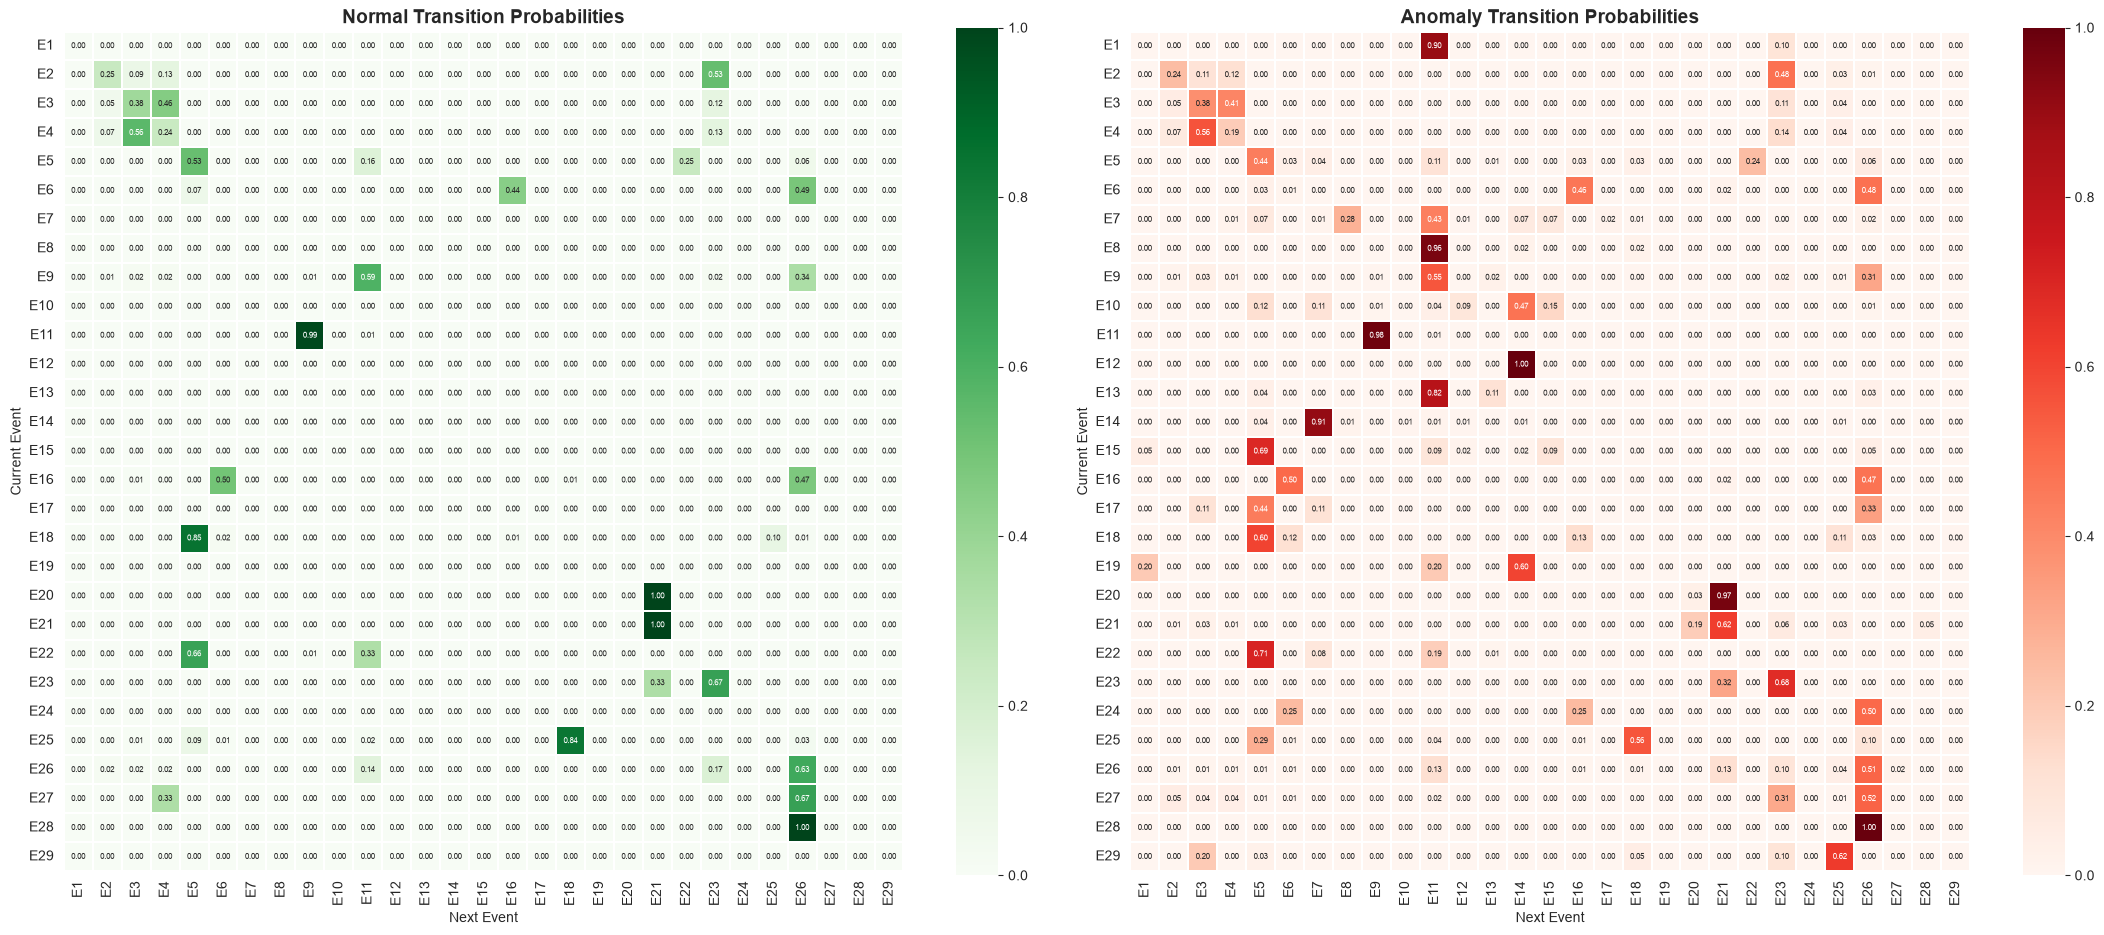

In [ ]:
#
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../outputs", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# -------------------------
# Normal
# -------------------------

sns.heatmap(
    normal_trans,
    ax=axes[0],
    cmap="Greens",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},
    linewidths=0.3,
    square=True
)

axes[0].set_title(
    "Normal Transition Probabilities",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Next Event")
axes[0].set_ylabel("Current Event")



sns.heatmap(
    anomaly_trans,
    ax=axes[1],
    cmap="Reds",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},
    linewidths=0.3,
    square=True
)

axes[1].set_title(
    "Anomaly Transition Probabilities",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Next Event")
axes[1].set_ylabel("Current Event")

plt.tight_layout()

plt.savefig(
    "../outputs/transition_matrices.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Step 7: Where Do Normal and Anomaly Flows Diverge?

By subtracting the two matrices (Anomaly - Normal), we get a **difference matrix**:
- **Positive values (red)**: This transition happens MORE in anomalies
- **Negative values (blue)**: This transition happens LESS in anomalies

The strongest red cells are the exact moments where the system's behavior shifts from healthy to failing.


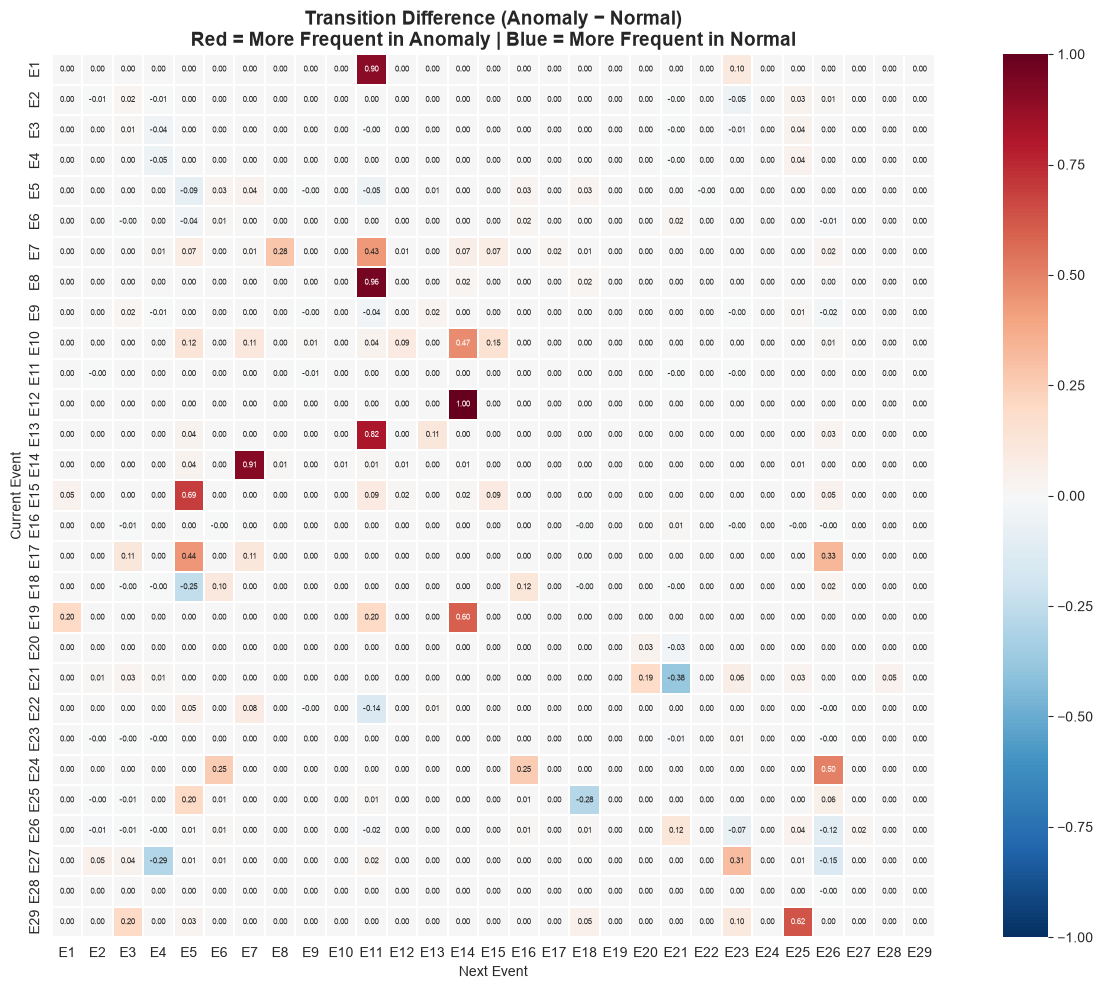


🔴 Transitions that INCREASE most in anomalies:

   E12 → E14: +1.000
   E8 → E11: +0.959
   E14 → E7: +0.910
   E1 → E11: +0.900
   E13 → E11: +0.816
   E15 → E5: +0.692
   E29 → E25: +0.625
   E19 → E14: +0.600
   E24 → E26: +0.500
   E10 → E14: +0.471

🔵 Transitions that DECREASE most in anomalies:

   E21 → E21: -0.380
   E27 → E4: -0.291
   E25 → E18: -0.281
   E18 → E5: -0.246
   E27 → E26: -0.150
   E22 → E11: -0.144
   E26 → E26: -0.117
   E5 → E5: -0.090
   E26 → E23: -0.073
   E2 → E23: -0.054


In [ ]:


diff_trans = anomaly_trans - normal_trans

# -------------------------
# Heatmap
# -------------------------

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    diff_trans,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},
    linewidths=0.3,
    square=True,
    ax=ax
)

ax.set_title(
    "Transition Difference (Anomaly − Normal)\n"
    "Red = More Frequent in Anomaly | Blue = More Frequent in Normal",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Next Event")
ax.set_ylabel("Current Event")

plt.tight_layout()

plt.savefig(
    "../outputs/transition_difference.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()



results = []

for current_event in diff_trans.index:
    for next_event in diff_trans.columns:

        results.append(
            (
                current_event,
                next_event,
                diff_trans.loc[current_event, next_event]
            )
        )


results_desc = sorted(results, key=lambda x: x[2], reverse=True)

print("\n Transitions that INCREASE most in anomalies:\n")

count = 0
for current_event, next_event, value in results_desc:

    if value <= 0.01:
        continue

    print(f"   {current_event} → {next_event}: +{value:.3f}")

    count += 1
    if count == 10:
        break



results_asc = sorted(results, key=lambda x: x[2])

print("\n🔵 Transitions that DECREASE most in anomalies:\n")

count = 0
for current_event, next_event, value in results_asc:

    if value >= -0.01:
        continue

    print(f"   {current_event} → {next_event}: {value:.3f}")

    count += 1
    if count == 10:
        break

##  Step 8: Anomaly Trace Archetypes

Instead of looking at individual bigrams, let's find the most COMMON complete sequence patterns. Since traces can be very long (200+ events), we'll look at the **unique "skeletons"** — the sequence with consecutive duplicates removed.

For example: `[E5, E5, E5, E22, E5, E3, E3, E3, E3]` → skeleton: `[E5, E22, E5, E3]`

This reveals the fundamental flow structure.


In [40]:
def get_skeleton(sequence):
    
    if not sequence:
        return tuple()
    skeleton = [sequence[0]]
    for event in sequence[1:]:
        if event != skeleton[-1]:
            skeleton.append(event)
    return tuple(skeleton)

# Get skeletons for normal and anomaly
traces_df['skeleton'] = traces_df['sequence'].apply(get_skeleton)

# Most common skeletons
normal_skeletons = Counter(traces_df[traces_df['Label']=='Success']['skeleton'].values)
anomaly_skeletons = Counter(traces_df[traces_df['Label']=='Fail']['skeleton'].values)

print(f"Unique skeleton patterns — Normal: {len(normal_skeletons):,}, Anomaly: {len(anomaly_skeletons):,}")

print(f"\n{'═'*70}")
print(f"  TOP 5 NORMAL FLOW PATTERNS")
print(f"{'═'*70}")
for skeleton, count in normal_skeletons.most_common(5):
    pct = count / len(normal_traces) * 100
    print(f"\n  Count: {count:,} ({pct:.1f}%)")
    print(f"  Flow:  {' → '.join(skeleton[:15])}")
    if len(skeleton) > 15:
        print(f"         ... ({len(skeleton)} events total)")

print(f"\n{'═'*70}")
print(f"  TOP 5 ANOMALY FLOW PATTERNS")
print(f"{'═'*70}")
for skeleton, count in anomaly_skeletons.most_common(5):
    pct = count / len(anomaly_traces) * 100
    print(f"\n  Count: {count:,} ({pct:.1f}%)")
    print(f"  Flow:  {' → '.join(skeleton[:15])}")
    if len(skeleton) > 15:
        print(f"         ... ({len(skeleton)} events total)")


Unique skeleton patterns — Normal: 5,250, Anomaly: 3,089

══════════════════════════════════════════════════════════════════════
  TOP 5 NORMAL FLOW PATTERNS
══════════════════════════════════════════════════════════════════════

  Count: 98,654 (17.7%)
  Flow:  E5 → E22 → E5 → E11 → E9 → E11 → E9 → E11 → E9 → E26 → E23 → E21

  Count: 94,794 (17.0%)
  Flow:  E5 → E22 → E11 → E9 → E11 → E9 → E11 → E9 → E26 → E23 → E21

  Count: 37,609 (6.7%)
  Flow:  E5 → E22 → E5 → E11 → E9 → E11 → E9 → E11 → E9 → E26

  Count: 31,213 (5.6%)
  Flow:  E5 → E22 → E11 → E9 → E11 → E9 → E11 → E9 → E26

  Count: 21,475 (3.8%)
  Flow:  E22 → E5 → E26 → E11 → E9 → E11 → E9 → E11 → E9 → E23 → E21

══════════════════════════════════════════════════════════════════════
  TOP 5 ANOMALY FLOW PATTERNS
══════════════════════════════════════════════════════════════════════

  Count: 1,643 (9.8%)
  Flow:  E5 → E22

  Count: 1,362 (8.1%)
  Flow:  E22 → E5 → E7

  Count: 1,307 (7.8%)
  Flow:  E22 → E5

  Count: 1,257 (

# Saving Finding to CoT agent:

In [ ]:
findings = {
    "anomaly_exclusive_bigrams": [
        {"from": bg[0], "to": bg[1], "count": count}
        for bg, count in sorted(anomaly_only_bigrams.items(), key=lambda x: x[1], reverse=True)[:30]
    ],
    "anomaly_exclusive_4grams": [
        {"pattern": list(fg), "count": count}
        for fg, count in sorted(anomaly_only_fourgrams.items(), key=lambda x: x[1], reverse=True)[:30]
    ],
    "top_normal_skeletons": [
        {"pattern": list(sk), "count": c}
        for sk, c in normal_skeletons.most_common(10)
    ],
    "top_anomaly_skeletons": [
        {"pattern": list(sk), "count": c}
        for sk, c in anomaly_skeletons.most_common(10)
    ],
}
output_path = '../data/sequence_analysis_findings.json'
with open(output_path, 'w') as f:
    json.dump(findings, f, indent=2)
print(f" Saved findings to {output_path}")

✅ Saved findings to ../data/sequence_analysis_findings.json


In [44]:
! jupyter nbconvert --to html 03_sequence_pattern_analysis.ipynb 

[NbConvertApp] Converting notebook 03_sequence_pattern_analysis.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 1260566 bytes to 03_sequence_pattern_analysis.html
